In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Google Drive is mounted.")

Mounted at /content/drive
Google Drive is mounted.


# Multimodal Model

In [ ]:
import os, copy, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torch.utils.checkpoint import checkpoint
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ───────────────────────────────────────────────
# Vs30 Lookup 생성
# ───────────────────────────────────────────────
def build_vs30_lookup_integrated(meta_csv_dict, shp_path,
                                 correction_mode="arv", vs30_ref=760.0,
                                 fallback_mode="median"):
    """
    4개 지진 meta CSV를 통합하여 seismic_station → vs30_feat(정규화 스칼라) 반환.
    동일 관측소가 여러 지진에 등장해도 중복 제거 후 처리.
    """
    all_meta = []
    for event, csv_path in meta_csv_dict.items():
        df = pd.read_csv(csv_path)
        df["seismic_station"] = df["seismic_station"].astype(str).str.strip().str.upper()
        df = df[["seismic_station", "seismic_lat", "seismic_lon"]].drop_duplicates("seismic_station")
        all_meta.append(df)
    meta_df = pd.concat(all_meta, ignore_index=True).drop_duplicates("seismic_station")

    lats, lons = meta_df["seismic_lat"].values, meta_df["seismic_lon"].values
    margin = 0.5
    bbox = (lons.min()-margin, lats.min()-margin, lons.max()+margin, lats.max()+margin)

    vs30_gdf = gpd.read_file(shp_path, bbox=bbox).to_crs("EPSG:4326")
    pts_gdf  = gpd.GeoDataFrame(
        meta_df.copy(),
        geometry=[Point(lo, la) for lo, la in zip(lons, lats)],
        crs="EPSG:4326"
    )
    joined = gpd.sjoin(pts_gdf, vs30_gdf[["AVS", "ARV", "geometry"]],
                       how="left", predicate="within")
    joined = joined.drop_duplicates(subset=["seismic_station"])
    meta_df = meta_df.copy()
    meta_df["vs30_avs"] = joined["AVS"].values
    meta_df["vs30_arv"] = joined["ARV"].values

    def get_amp(row):
        if correction_mode == "arv":
            v = row["vs30_arv"]
            return float(v) if pd.notna(v) and v > 0 else np.nan
        else:
            v = row["vs30_avs"]
            if pd.isna(v) or v <= 0: return np.nan
            return float(np.exp(-0.84 * np.log(np.clip(v, 100., 2000.) / vs30_ref)))

    meta_df["amp_factor"] = meta_df.apply(get_amp, axis=1)
    valid = meta_df["amp_factor"].dropna()
    fallback = float(valid.median()) if fallback_mode == "median" else float(fallback_mode)
    meta_df["amp_factor"] = meta_df["amp_factor"].fillna(fallback)

    # log 변환 후 Z-score 정규화
    log_amps = np.log(meta_df["amp_factor"].clip(lower=1e-3))
    mu, sigma = log_amps.mean(), log_amps.std()
    sigma = sigma if sigma > 1e-8 else 1.0
    meta_df["vs30_feat"] = (log_amps - mu) / sigma

    lookup = dict(zip(meta_df["seismic_station"], meta_df["vs30_feat"]))
    print(f"[Vs30] 통합 lookup: {len(lookup)}개 관측소 | fallback={fallback:.4f} | "
          f"log_amp μ={mu:.4f} σ={sigma:.4f}")
    return lookup

# ───────────────────────────────────────────────
# 데이터 경로 (수정정 코드 경로 그대로 유지)
# ───────────────────────────────────────────────
all_pgv_path = "/content/drive/MyDrive/TriAI/그로쓰/Data/processed/multimodal/추가 실험/통합/pgv_all.csv"
all_seismic_path = "/content/drive/MyDrive/TriAI/그로쓰/Data/processed/multimodal/추가 실험/통합/seismic_all.npz"
all_gnss_path = "/content/drive/MyDrive/TriAI/그로쓰/Data/processed/multimodal/추가 실험/통합/gnss_all.npz"

META_CSV = {
    "tohoku":   f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/tohoku/tohoku_station_pairs_ver_25km.csv",
    "noto":     f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/noto/noto_station_pairs_ver_25km.csv",
    "hokkaido": f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/hokkaido/hokkaido_station_pairs_ver_25km.csv",
    "kumamoto": f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/kumamoto/kumamoto_station_pairs_ver_25km.csv",
}

VS30_SHP = f"/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/vs30 데이터/Z-V4-JAPAN-AMP-VS400_M250-SHAPE.shp"


# ───────────────────────────────────────────────
# Dataset
# ───────────────────────────────────────────────
class MultimodalDataset(Dataset):
    def __init__(self, seismic_npz, gnss_npz, pgv_csv,
                 target_events,          # 이 Dataset에 포함할 이벤트 리스트
                 is_train=True,
                 y_mean=None, y_std=None, vs30_dict=None):
        """
        target_events: e.g. ['tohoku','noto','kumamoto'] for train,
                            ['hokkaido'] for test
        y_mean/y_std: 외부에서 계산된 통합 정규화 통계 (train/test 공유)
        """
        seismic_data = np.load(seismic_npz, allow_pickle=True)
        gnss_data    = np.load(gnss_npz,    allow_pickle=True)
        pgv_data     = pd.read_csv(pgv_csv)

        self.seismic = seismic_data['data']          # (N, W, T_s, C)
        self.gnss    = gnss_data['data']             # (N, W, T_g, C)
        self.seismic_station = seismic_data['station_names']  # (N,)
        self.event_names     = seismic_data['name']           # (N,) 지진 이벤트명

        self.pgv_dict = dict(zip(
            pgv_data['seismic_station'].astype(str).str.strip(),
            pgv_data['pgv']
        ))
        self.is_train  = is_train
        self.vs30_dict = vs30_dict if vs30_dict is not None else {}

        # target_events에 속하고 PGV 라벨이 있는 인덱스만 선택
        target_set = set(target_events)
        self.valid_indices = [
            i for i in range(len(self.seismic))
            if (str(self.event_names[i]).strip() in target_set and
                str(self.seismic_station[i]).strip().strip("[]'\"") in self.pgv_dict)
        ]
        print(f"[Dataset] events={target_events} | 유효 샘플: {len(self.valid_indices)}")

        # 통합 정규화: 외부에서 계산된 y_mean/y_std 사용
        assert y_mean is not None and y_std is not None, \
        self.y_mean = y_mean
        self.y_std  = y_std

        #  WeightedRandomSampler를 위한 이벤트별 가중치
        # 각 샘플이 어느 이벤트인지 기록 → 외부에서 sampler 생성에 사용
        self.sample_events = [
            str(self.event_names[i]).strip() for i in self.valid_indices
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        raw_idx = self.valid_indices[idx]
        seismic = np.copy(self.seismic[raw_idx])  # (W, T_s, C)
        gnss    = np.copy(self.gnss[raw_idx])    # (W, T_g, C)

        station = str(self.seismic_station[raw_idx]).strip().strip("[]'\"")
        raw_pgv = self.pgv_dict.get(station, 0.0)
        pgv_label = (np.log1p(raw_pgv) - self.y_mean) / self.y_std

        # 데이터 증강 (학습 시에만)
        if self.is_train:
            if random.random() < 0.3:
                seismic += np.random.normal(0, 0.05, seismic.shape).astype(np.float32)
                gnss    += np.random.normal(0, 0.05, gnss.shape).astype(np.float32)
            if random.random() < 0.2:
                seismic[:, :, random.randint(0, 2)] = 0
            if random.random() < 0.2:
                gnss[:, :, random.randint(0, 2)]    = 0

        # 정규화 (시간축 기준)
        seismic = seismic.astype(np.float32)
        s_mean  = seismic.mean(axis=1, keepdims=True)
        s_std   = seismic.std(axis=1,  keepdims=True).clip(min=1e-8)
        seismic = (seismic - s_mean) / s_std

        gnss    = gnss.astype(np.float32)
        g_mean  = gnss.mean(axis=1, keepdims=True)
        g_std   = gnss.std(axis=1,  keepdims=True).clip(min=1e-8)
        gnss    = (gnss - g_mean) / g_std

        # seismic: (W, T_s, C) → (W, C, T_s)  Conv1d용
        seismic_t = torch.tensor(seismic.transpose(0, 2, 1), dtype=torch.float32)
        gnss_t    = torch.tensor(gnss,                        dtype=torch.float32)
        y_t       = torch.tensor([pgv_label],                 dtype=torch.float32)

        vs30_val = float(self.vs30_dict.get(station.upper(), 0.0))
        vs30_t   = torch.tensor([vs30_val], dtype=torch.float32)

        return seismic_t, gnss_t, y_t, station, vs30_t

def compute_combined_stats(pgv_csv, train_events):
    """
    train_events에 속하는 샘플만으로 y_mean/y_std 계산
    test 이벤트의 PGV는 정규화 통계에 포함하지 않음
    """
    df = pd.read_csv(pgv_csv)
    train_df = df[df['name'].isin(train_events)]
    log_pgv  = np.log1p(train_df['pgv'].values.astype(np.float32))
    y_mean   = float(np.mean(log_pgv))
    y_std    = float(np.std(log_pgv))
    y_std    = y_std if y_std > 1e-8 else 1.0
    print(f"[Combined Stats] train_events={train_events} | "
          f"y_mean={y_mean:.6f}, y_std={y_std:.6f} (n={len(log_pgv)})")
    return y_mean, y_std


# ───────────────────────────────────────────────
# Seismic Encoder
# ───────────────────────────────────────────────
class ResNetBlock(nn.Module):
    def __init__(self, filters, kernel_size, drop_rate):
        super().__init__()
        pad = kernel_size // 2
        self.bn1   = nn.BatchNorm1d(filters)
        self.drop1 = nn.Dropout1d(drop_rate)
        self.conv1 = nn.Conv1d(filters, filters, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(filters)
        self.drop2 = nn.Dropout1d(drop_rate)
        self.conv2 = nn.Conv1d(filters, filters, kernel_size, padding=pad)

    def forward(self, x):
        out = self.conv1(self.drop1(F.relu(self.bn1(x))))
        out = self.conv2(self.drop2(F.relu(self.bn2(out))))
        return out + x


class BiLSTMBlock(nn.Module):
    def __init__(self, in_channels, hidden, drop_rate):
        super().__init__()
        self.drop_rate = drop_rate
        self.bilstm = nn.LSTM(in_channels, hidden, batch_first=True, bidirectional=True)
        self.nin    = nn.Conv1d(hidden * 2, hidden, 1)
        self.bn     = nn.BatchNorm1d(hidden)

    def forward(self, x):           # (B, C, T)
        x = F.dropout(x.permute(0, 2, 1), p=self.drop_rate, training=self.training)
        out, _ = self.bilstm(x)     # (B, T, 2H)
        out = self.nin(out.permute(0, 2, 1))
        return self.bn(out)


class SeismicEncoder(nn.Module):
    """
    Input : (B, 3, T_s)  — 100Hz 원본
    Output: (B, T_s', output_dim)
    MaxPool 3회 (1/8) + avg_pool 4 = 총 1/32 압축
    """
    def __init__(self, in_ch=3, drop_rate=0.2, output_dim=128):
        super().__init__()
        # (out_ch, kernel, pool여부)
        cfg = [
            (8,  11, True),
            (16,  9, True),
            (16,  7, True),
            (32,  7, False),
            (32,  5, False),
            (96,  5, False),
            (96,  3, False),
        ]
        self.convs = nn.ModuleList()
        c = in_ch
        for out_c, k, pool in cfg:
            layers = [nn.Conv1d(c, out_c, k, padding=k//2), nn.ReLU()]
            if pool:
                layers.append(nn.MaxPool1d(2))
            self.convs.append(nn.Sequential(*layers))
            c = out_c

        self.res_blocks = nn.ModuleList(
            [ResNetBlock(96, 3, drop_rate) for _ in range(5)]
        )

        lstm_hidden = 64
        self.bilstm_blocks = nn.ModuleList()
        lc = 96
        for _ in range(2):
            self.bilstm_blocks.append(BiLSTMBlock(lc, lstm_hidden, drop_rate))
            lc = lstm_hidden

        enc_layer = nn.TransformerEncoderLayer(
            d_model=lstm_hidden, nhead=4, dim_feedforward=256,
            dropout=drop_rate, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.proj = nn.Linear(lstm_hidden, output_dim)

    def forward(self, x):
        for conv in self.convs:
            x = checkpoint(conv, x, use_reentrant=False)
        for res in self.res_blocks:
            x = checkpoint(res, x, use_reentrant=False)
        for bilstm in self.bilstm_blocks:
            x = checkpoint(bilstm, x, use_reentrant=False)
        x = F.avg_pool1d(x, kernel_size=4, stride=4)
        x = self.transformer(x.permute(0, 2, 1))
        return self.proj(x)          # (B, T_s', output_dim)


# ───────────────────────────────────────────────
# GNSS Encoder
# ───────────────────────────────────────────────
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=7, dropout=0.2):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(in_ch,  out_ch, k, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if in_ch != out_ch else None

    def forward(self, x):
        shortcut = self.proj(x) if self.proj else x
        out = self.drop(F.relu(self.bn1(self.conv1(x))))
        return F.relu(self.bn2(self.conv2(out)) + shortcut)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads=2, dropout=0.1, ff_mult=2):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mult), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model * ff_mult, d_model)
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.mha(x, x, x)
        x = self.ln1(x + attn_out)
        return self.ln2(x + self.ffn(x))


class GNSSEncoder(nn.Module):
    """
    Input : (B, T_g, 3)  — 1Hz GNSS
    Output: (B, T_g, 128)
    """
    def __init__(self, in_ch=3, base_filters=48, res_depth=3,
                 lstm_units=64, num_heads=2, dropout=0.15, k=7):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, base_filters, k, padding=k//2, bias=False),
            nn.BatchNorm1d(base_filters), nn.ReLU()
        )
        self.res = nn.Sequential(*[
            ResBlock1D(base_filters, base_filters, k=k, dropout=dropout)
            for _ in range(res_depth)
        ])
        self.bilstm = nn.LSTM(base_filters, lstm_units, batch_first=True, bidirectional=True)
        self.tx = TransformerBlock(2 * lstm_units, num_heads=num_heads, dropout=dropout)

    def forward(self, x):           # (B, T_g, 3)
        x = self.stem(x.transpose(1, 2))   # (B, base_filters, T_g)
        x = self.res(x).transpose(1, 2)    # (B, T_g, base_filters)
        x, _ = self.bilstm(x)              # (B, T_g, 128)
        return self.tx(x)


# ───────────────────────────────────────────────
# CrossScaleUMIS
# ───────────────────────────────────────────────
class CrossModalAttention(nn.Module):
    """T_q != T_kv 완전 허용하는 Cross-Attention"""
    def __init__(self, query_dim, kv_dim, out_dim, num_heads=4, dropout=0.1):
        super().__init__()
        assert out_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = out_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.q_proj   = nn.Linear(query_dim, out_dim)
        self.k_proj   = nn.Linear(kv_dim,    out_dim)
        self.v_proj   = nn.Linear(kv_dim,    out_dim)
        self.out_proj = nn.Linear(out_dim,   out_dim)
        self.dropout  = nn.Dropout(dropout)
        self.norm     = nn.LayerNorm(out_dim)
        self.res_proj = nn.Linear(query_dim, out_dim) if query_dim != out_dim else nn.Identity()

    def forward(self, query, key_value):
        B, T_q, _ = query.shape
        _, T_kv, _ = key_value.shape
        H, Dh = self.num_heads, self.head_dim

        q = self.q_proj(query).view(B, T_q,  H, Dh).transpose(1, 2)
        k = self.k_proj(key_value).view(B, T_kv, H, Dh).transpose(1, 2)
        v = self.v_proj(key_value).view(B, T_kv, H, Dh).transpose(1, 2)

        attn = self.dropout(torch.softmax(
            torch.matmul(q, k.transpose(-2, -1)) * self.scale, dim=-1
        ))
        out = self.out_proj(
            torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, T_q, -1)
        )
        return self.norm(self.res_proj(query) + out)


class CrossScaleUMIS(nn.Module):
    def __init__(self, seismic_dim=128, gnss_dim=128, umis_dim=128, num_heads=4, dropout=0.1):
        super().__init__()
        self.proj_s = nn.Sequential(
            nn.Linear(seismic_dim, umis_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(umis_dim, umis_dim), nn.LayerNorm(umis_dim)
        )
        self.proj_g = nn.Sequential(
            nn.Linear(gnss_dim, umis_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(umis_dim, umis_dim), nn.LayerNorm(umis_dim)
        )
        self.emb_s = nn.Parameter(torch.randn(1, 1, umis_dim) * 0.02)
        self.emb_g = nn.Parameter(torch.randn(1, 1, umis_dim) * 0.02)

        self.s_attn_g = CrossModalAttention(umis_dim, umis_dim, umis_dim, num_heads, dropout)
        self.g_attn_s = CrossModalAttention(umis_dim, umis_dim, umis_dim, num_heads, dropout)

        self.gate_s = nn.Sequential(nn.Linear(umis_dim * 2, umis_dim), nn.Sigmoid())
        self.gate_g = nn.Sequential(nn.Linear(umis_dim * 2, umis_dim), nn.Sigmoid())
        nn.init.constant_(self.gate_s[0].bias, -5.0)
        nn.init.constant_(self.gate_g[0].bias, -5.0)

        self.fusion = nn.Sequential(
            nn.Linear(umis_dim * 2, umis_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(umis_dim, umis_dim), nn.LayerNorm(umis_dim)
        )

    def forward(self, f_s, f_g):
        h_s = self.proj_s(f_s) + self.emb_s   # (B, T_s, D)
        h_g = self.proj_g(f_g) + self.emb_g   # (B, T_g, D)

        h_s_from_g = self.s_attn_g(h_s, h_g)  # T_s query, T_g kv — 길이 불일치 OK
        h_g_from_s = self.g_attn_s(h_g, h_s)

        gate_s    = self.gate_s(torch.cat([h_s, h_s_from_g], dim=-1))
        h_s_fused = h_s + gate_s * (h_s_from_g - h_s)

        h_g_pooled = h_g_from_s.mean(dim=1, keepdim=True).expand_as(h_s)
        gate_g     = self.gate_g(torch.cat([h_s, h_g_pooled], dim=-1))
        h_g_contrib = gate_g * h_g_pooled

        return self.fusion(torch.cat([h_s_fused, h_s + h_g_contrib], dim=-1))


# ───────────────────────────────────────────────
# Decoder
# ───────────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=1, dropout=0.3):
        super().__init__()
        self.attn_pool = nn.Linear(input_dim, 1)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),  # +1 for vs30
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.reg = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x, vs30):             # vs30: (B, 1)
        w   = torch.softmax(self.attn_pool(x).squeeze(-1), dim=1).unsqueeze(-1)
        ctx = (x * w).sum(dim=1)            # (B, D)
        ctx = torch.cat([ctx, vs30], dim=-1) # (B, D+1)
        return self.reg(self.mlp(ctx))


# ───────────────────────────────────────────────
# MultimodalModel
# ───────────────────────────────────────────────
class MultimodalModel(nn.Module):
    def __init__(self, umis_dim=128):
        super().__init__()
        self.seismic_encoder = SeismicEncoder(output_dim=128)
        self.gnss_encoder    = GNSSEncoder()
        self.umis            = CrossScaleUMIS(seismic_dim=128, gnss_dim=128, umis_dim=umis_dim)
        self.decoder         = Decoder(input_dim=umis_dim, hidden_dim=64)

    def forward(self, x_s, x_g, vs30):
        # x_s: (B, W, C, T_s)
        # x_g: (B, W, T_g, C)
        B, W, C, T_s = x_s.shape
        _, _, T_g, _ = x_g.shape

        s_flat = x_s.view(B * W, C, T_s)       # (BW, C, T_s)
        g_flat = x_g.view(B * W, T_g, C)       # (BW, T_g, C)

        f_s = self.seismic_encoder(s_flat)      # (BW, T_s', 128)
        f_g = self.gnss_encoder(g_flat)         # (BW, T_g,  128)

        fused = self.umis(f_s, f_g)             # (BW, T_s', 128)

        _, T_out, D = fused.shape
        fused = fused.view(B, W * T_out, D)     # (B, W*T_out, 128)
        return self.decoder(fused, vs30)


# 학습 설정
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

BATCH_SIZE    = 16
NUM_EPOCHS    = 100
LEARNING_RATE = 3e-4
PATIENCE      = 40


def make_weighted_sampler(dataset):
    """
    각 이벤트에 1/count 가중치를 부여하여 불균형 완화
    hokkaido(120), kumamoto(102) 같은 소수 이벤트도 균등하게 학습
    """
    event_names   = dataset.sample_events
    unique_events = list(set(event_names))
    event_count   = {e: event_names.count(e) for e in unique_events}
    print(f"[Sampler] 이벤트별 샘플 수: {event_count}")

    weights = [1.0 / event_count[e] for e in event_names]
    weights = torch.tensor(weights, dtype=torch.float32)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return sampler

def get_cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs, min_lr_ratio=0.05):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class PGVWeightedLoss(nn.Module):
    def __init__(self, alpha=0.5, delta=1.0):
        super().__init__()
        self.alpha = alpha
        self.huber = nn.HuberLoss(delta=delta, reduction='none')
        self.mse   = nn.MSELoss(reduction='none')

    def forward(self, pred, target):
        weight   = 1.0 + torch.abs(target) ** 2
        combined = self.alpha * self.mse(pred, target) + \
                   (1 - self.alpha) * self.huber(pred, target)
        return (combined * weight).mean()

# ───────────────────────────────────────────────
# 시각화 유틸
# ───────────────────────────────────────────────
def summarize(metric, experiment_name):
    best_epoch = metric['val_rmse'].index(min(metric['val_rmse'])) + 1
    print(f"\n====================================================================")
    print(f"[{experiment_name}] 학습 결과 요약")
    print(f"====================================================================")
    print(f"  Best Val RMSE    : {min(metric['val_rmse']):.2f}  (Epoch {best_epoch})")
    print(f"  Val Loss 스파이크: {sum(1 for v in metric['val_loss'] if v > 10)}회")
    print(f"  최종 Train Loss  : {metric['train_loss'][-1]:.4f}")
    print(f"  최종 Val Loss    : {metric['val_loss'][-1]:.4f}")
    if 'test_loss' in metric and 'test_rmse' in metric:
        print(f"--------------------------------------------------------------------")
        print(f"  최종 Test Loss   : {metric['test_loss']:.4f}")
        print(f"  최종 Test RMSE   : {metric['test_rmse']:.2f}")
    print(f"====================================================================")


def plot_best_model_predictions(model, loader, device, title_name, y_mean, y_std):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for x_s, x_g, targets, _, vs30 in loader:
            outputs = model(x_s.to(device), x_g.to(device), vs30.to(device))
            actuals.extend(targets.numpy().flatten())
            predictions.extend(outputs.cpu().numpy().flatten())

    act_orig  = np.expm1(np.array(actuals)      * y_std + y_mean)
    pred_orig = np.expm1(np.array(predictions)  * y_std + y_mean)

    plt.figure(figsize=(10, 10))
    plt.scatter(act_orig, pred_orig, alpha=0.5, color='dodgerblue', edgecolor='k', s=50)
    max_val = 100
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.plot([0, max_val], [10, max_val+10], color='gray', linestyle=':', alpha=0.7, label='+10 Error')
    plt.plot([0, max_val], [-10, max_val-10], color='gray', linestyle=':', alpha=0.7, label='-10 Error')
    plt.title(f'[{title_name}] Best Model: Actual vs Predicted', fontsize=16, fontweight='bold')
    plt.xlabel('Actual PGV', fontsize=14); plt.ylabel('Predicted PGV', fontsize=14)
    plt.xlim(0, max_val); plt.ylim(0, max_val)
    plt.grid(True, linestyle='--', alpha=0.6); plt.legend(fontsize=12)
    plt.tight_layout(); plt.show()


# ───────────────────────────────────────────────
# 학습 루프
# ───────────────────────────────────────────────
def main(test_event="noto"):
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # 통합 정규화 통계 (train 이벤트 PGV만으로 계산)
    all_event_names = list(META_CSV.keys())
    train_events_list = [event for event in all_event_names if event != test_event]

    y_mean, y_std = compute_combined_stats(all_pgv_path, train_events_list)

    train_dataset    = MultimodalDataset(all_seismic_path, all_gnss_path, all_pgv_path,
                                         target_events=train_events_list,
                                         is_train=True, y_mean=y_mean, y_std=y_std, vs30_dict=vs30_lookup)
    val_test_dataset = MultimodalDataset(all_seismic_path, all_gnss_path, all_pgv_path,
                                         target_events=[test_event],
                                         is_train=False, y_mean=y_mean, y_std=y_std, vs30_dict=vs30_lookup)
    print(f">> Train: {test_event} 제외 나머지 세 지진 / Val+Test: {test_event}")

    n_val  = int(len(val_test_dataset) * 0.2)
    n_test = len(val_test_dataset) - n_val
    val_dataset, test_dataset = random_split(
        val_test_dataset, [n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    sampler      = make_weighted_sampler(train_dataset)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False,  drop_last=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = MultimodalModel().to(device)
    criterion = PGVWeightedLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
    scheduler = get_cosine_warmup_scheduler(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS)
    scaler    = GradScaler()

    ym, ys = train_dataset.y_mean, train_dataset.y_std
    best_val_rmse    = float('inf')
    best_weights     = None
    patience_counter = 0
    metrics = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_rmse': [], 'lr': [], 'y_mean': ym, 'y_std': ys
    }

    print("============================== Train ==============================")
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0
        for x_s, x_g, y, _, vs30 in train_loader:
            x_s, x_g, y, vs30 = x_s.to(device), x_g.to(device), y.to(device), vs30.to(device)
            optimizer.zero_grad()
            with autocast():
                loss = criterion(model(x_s, x_g, vs30), y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss, val_preds, val_tgts = 0.0, [], []
        with torch.no_grad():
            for x_s, x_g, y, _, vs30 in val_loader:
                x_s, x_g, y, vs30 = (x_s.to(device), x_g.to(device), y.to(device), vs30.to(device))
                with autocast():
                    out = model(x_s, x_g, vs30)
                val_loss += criterion(out, y).item()
                val_preds.extend(out.cpu().numpy().flatten())
                val_tgts.extend(y.cpu().numpy().flatten())
        avg_val = val_loss / len(val_loader)

        scheduler.step()
        cur_lr = optimizer.param_groups[0]['lr']

        vp = np.expm1(np.array(val_preds) * ys + ym)
        vt = np.expm1(np.array(val_tgts)  * ys + ym)
        val_rmse = float(np.sqrt(np.mean((vp - vt) ** 2)))

        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(avg_train)
        metrics['val_loss'].append(avg_val)
        metrics['val_rmse'].append(val_rmse)
        metrics['lr'].append(cur_lr)

        if val_rmse < best_val_rmse:
            best_val_rmse    = val_rmse
            best_weights     = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  [Patience {PATIENCE}] Best model 가중치 복원 후 계속 학습")
            model.load_state_dict(best_weights)
            patience_counter = 0

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] LR: {cur_lr:.6f} | "
              f"Train: {avg_train:.4f} | Val: {avg_val:.4f} (RMSE: {val_rmse:.2f})")

    model.load_state_dict(best_weights)
    torch.save(best_weights, f'best_test_{test_event}_model.pth')

    print("\n=============================== Test ===============================")
    model.eval()
    test_loss, test_preds, test_tgts, test_stations = 0.0, [], [], []
    with torch.no_grad():
        for x_s, x_g, y, stations, vs30 in test_loader:
            x_s, x_g, y, vs30 = (x_s.to(device), x_g.to(device), y.to(device), vs30.to(device))
            with autocast():
                out = model(x_s, x_g, vs30)
            test_loss += criterion(out, y).item()
            test_preds.extend(out.cpu().numpy().flatten())
            test_tgts.extend(y.cpu().numpy().flatten())
            test_stations.extend(stations)

    tp = np.expm1(np.array(test_preds) * ys + ym)
    tt = np.expm1(np.array(test_tgts)  * ys + ym)
    test_rmse = float(np.sqrt(np.mean((tp - tt) ** 2)))
    print(f"Final Test Loss: {test_loss/len(test_loader):.4f} | Test RMSE: {test_rmse:.2f}")

    metrics['test_loss'] = test_loss / len(test_loader)
    metrics['test_rmse'] = test_rmse

    # CSV 저장
    result_df = pd.DataFrame({
        "seismic_station": test_stations,
        "pgv_true": tt,
        "pgv_pred": tp,
    })
    SAVE_DIR = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험"
    save_name = os.path.join(SAVE_DIR, f"{test_event}_predicted_pgv_25km_360_180.csv")
    result_df.to_csv(save_name, index=False)
    print(f"[저장 완료] {save_name}")

    return model, metrics, test_loader

# [실험 1] Train: Tohoku, Kumamoto, Hokkaido / Test: Noto

=== Vs30 Lookup 빌드 ===
[Vs30] 통합 lookup: 280개 관측소 | fallback=0.9533 | log_amp μ=-0.0317 σ=0.2825
===== [실험 1] Train: Tohoku, Kumamoto, Hokkaido / Test: Noto ====

Device: cuda
[Combined Stats] train_events=['tohoku', 'hokkaido', 'kumamoto'] | y_mean=2.110529, y_std=0.960822 (n=394)
[Dataset] events=['tohoku', 'hokkaido', 'kumamoto'] | 유효 샘플: 394
[Dataset] events=['noto'] | 유효 샘플: 176
>> Train: noto 제외 나머지 세 지진 / Val+Test: noto
[Sampler] 이벤트별 샘플 수: {'tohoku': 172, 'kumamoto': 102, 'hokkaido': 120}
============================== Train ==============================


/tmp/ipykernel_1082/406844175.py:642: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_1082/406844175.py:660: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1082/406844175.py:675: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 2.2348 | Val: 3.0278 (RMSE: 13.68)
Epoch [2/100] LR: 0.000180 | Train: 2.6504 | Val: 4.0256 (RMSE: 13.45)
Epoch [3/100] LR: 0.000240 | Train: 1.5535 | Val: 2.0137 (RMSE: 13.74)
Epoch [4/100] LR: 0.000300 | Train: 1.5248 | Val: 1.8634 (RMSE: 14.05)
Epoch [5/100] LR: 0.000300 | Train: 1.3933 | Val: 1.5020 (RMSE: 13.32)
Epoch [6/100] LR: 0.000300 | Train: 1.3646 | Val: 1.6456 (RMSE: 13.85)
Epoch [7/100] LR: 0.000300 | Train: 1.2962 | Val: 1.6928 (RMSE: 10.82)
Epoch [8/100] LR: 0.000299 | Train: 1.1328 | Val: 2.0643 (RMSE: 10.88)
Epoch [9/100] LR: 0.000299 | Train: 1.4567 | Val: 0.8941 (RMSE: 11.78)
Epoch [10/100] LR: 0.000298 | Train: 1.1691 | Val: 2.5355 (RMSE: 11.36)
Epoch [11/100] LR: 0.000297 | Train: 1.1383 | Val: 1.4733 (RMSE: 14.08)
Epoch [12/100] LR: 0.000296 | Train: 0.9434 | Val: 1.0052 (RMSE: 12.73)
Epoch [13/100] LR: 0.000295 | Train: 1.0595 | Val: 1.0499 (RMSE: 13.23)
Epoch [14/100] LR: 0.000294 | Train: 0.6765 | Val: 0.8767 (RMSE: 12.16)
E

/tmp/ipykernel_1082/406844175.py:719: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 0.3079 | Test RMSE: 9.92
[저장 완료] /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/noto_predicted_pgv_25km_360_180.csv

[Train: Tohoku, Kumamoto, Hokkaido -> Test: Noto] 학습 결과 요약
  Best Val RMSE    : 6.45  (Epoch 93)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.4109
  최종 Val Loss    : 0.2632
--------------------------------------------------------------------
  최종 Test Loss   : 0.3079
  최종 Test RMSE   : 9.92


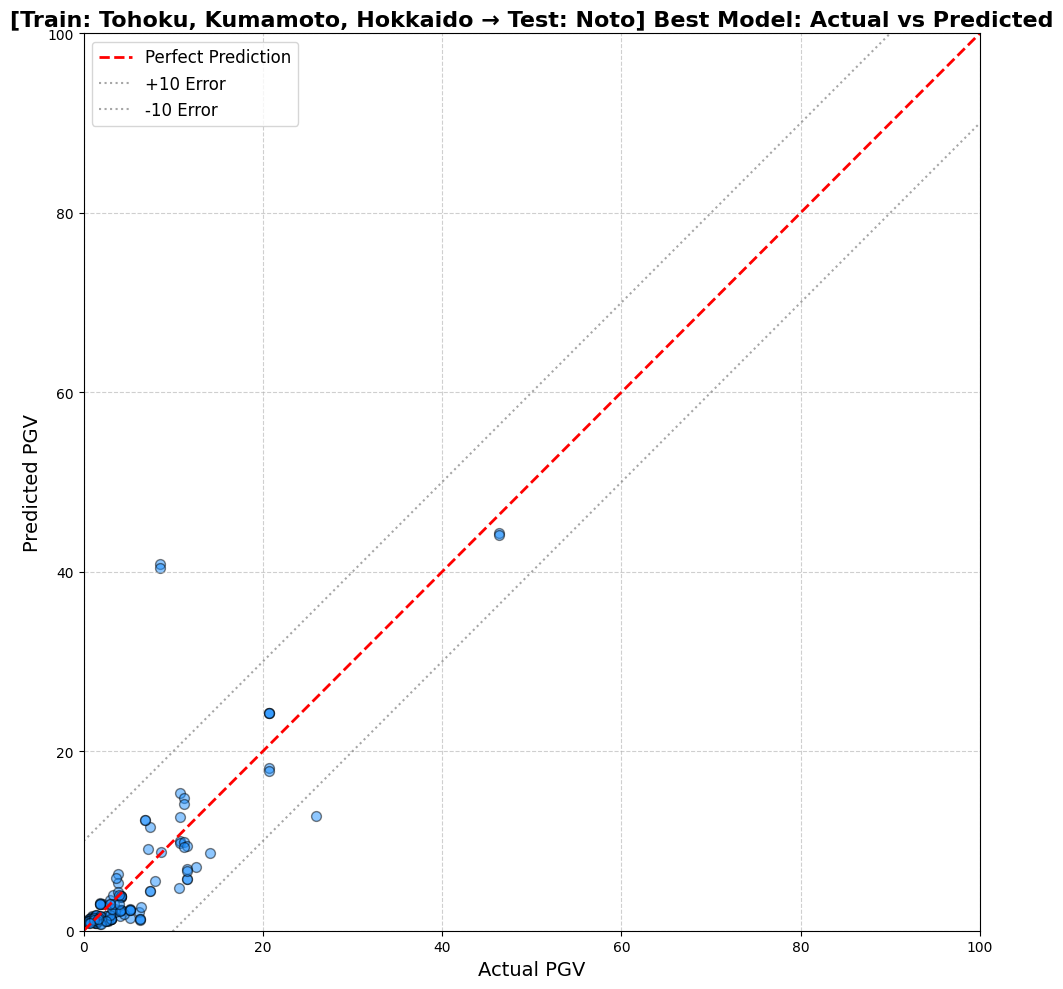

In [ ]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 추가
    print("=== Vs30 Lookup 빌드 ===")
    vs30_lookup = build_vs30_lookup_integrated(META_CSV, VS30_SHP)

    print("===== [실험 1] Train: Tohoku, Kumamoto, Hokkaido / Test: Noto ====\n")
    best_model_2n, metric_2n, test_loader_2n = main(test_event="noto")

    summarize(metric_2n, "Train: Tohoku, Kumamoto, Hokkaido -> Test: Noto")

    plot_best_model_predictions(best_model_2n, test_loader_2n, device, "Train: Tohoku, Kumamoto, Hokkaido → Test: Noto",
                                y_mean=metric_2n['y_mean'], y_std=metric_2n['y_std'])

# ───────────────────────────────────────────────
# 결과 저장
# ───────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/TriAI/그로쓰/Data/npy/multimodal/추가실험"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_metric_npy(metric, filename_prefix, save_dir=SAVE_DIR):
    save_data = {
        'epoch':      np.array(metric['epoch'],      dtype=np.int32),
        'train_loss': np.array(metric['train_loss'], dtype=np.float32),
        'test_loss':  np.float32(metric['test_loss']),
        'test_rmse':  np.float32(metric['test_rmse']),
        'lr':         np.array(metric['lr'],         dtype=np.float32)
    }
    save_path = os.path.join(save_dir, f"{filename_prefix}.npy")
    np.save(save_path, save_data)
    print(f"[저장 완료] {save_path}")
    return save_path

# [실험 2] Train: Tohoku, Kumamoto, Noto / Test: Hokkaido

===== [실험 2] Train: Tohoku, Kumamoto, Noto / Test: Hokkaido ====

Device: cuda
[Combined Stats] train_events=['tohoku', 'noto', 'kumamoto'] | y_mean=2.079253, y_std=0.942309 (n=450)
[Dataset] events=['tohoku', 'noto', 'kumamoto'] | 유효 샘플: 450
[Dataset] events=['hokkaido'] | 유효 샘플: 120
>> Train: hokkaido 제외 나머지 세 지진 / Val+Test: hokkaido
[Sampler] 이벤트별 샘플 수: {'tohoku': 172, 'kumamoto': 102, 'noto': 176}
============================== Train ==============================


/tmp/ipykernel_1082/406844175.py:642: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_1082/406844175.py:660: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 2.4085 | Val: 2.5150 (RMSE: 4.81)


/tmp/ipykernel_1082/406844175.py:675: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] LR: 0.000180 | Train: 2.1910 | Val: 1.4608 (RMSE: 4.42)
Epoch [3/100] LR: 0.000240 | Train: 1.7223 | Val: 4.5718 (RMSE: 8.11)
Epoch [4/100] LR: 0.000300 | Train: 1.2824 | Val: 0.7770 (RMSE: 3.39)
Epoch [5/100] LR: 0.000300 | Train: 1.4765 | Val: 2.6370 (RMSE: 6.38)
Epoch [6/100] LR: 0.000300 | Train: 1.3705 | Val: 0.8353 (RMSE: 4.91)
Epoch [7/100] LR: 0.000300 | Train: 1.0911 | Val: 0.6812 (RMSE: 4.83)
Epoch [8/100] LR: 0.000299 | Train: 1.0446 | Val: 3.3309 (RMSE: 8.56)
Epoch [9/100] LR: 0.000299 | Train: 1.1976 | Val: 0.8744 (RMSE: 5.36)
Epoch [10/100] LR: 0.000298 | Train: 0.8590 | Val: 1.9578 (RMSE: 5.79)
Epoch [11/100] LR: 0.000297 | Train: 0.8461 | Val: 0.5938 (RMSE: 4.78)
Epoch [12/100] LR: 0.000296 | Train: 0.8653 | Val: 0.7530 (RMSE: 3.09)
Epoch [13/100] LR: 0.000295 | Train: 0.6993 | Val: 0.5178 (RMSE: 3.44)
Epoch [14/100] LR: 0.000294 | Train: 0.7603 | Val: 0.6067 (RMSE: 4.78)
Epoch [15/100] LR: 0.000292 | Train: 0.8632 | Val: 0.3849 (RMSE: 3.72)
Epoch [16/100]

/tmp/ipykernel_1082/406844175.py:719: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 0.8507 | Test RMSE: 7.80
[저장 완료] /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/hokkaido_predicted_pgv_25km_360_180.csv

[Train: Tohoku, Kumamoto, Noto -> Test: Hokkaido] 학습 결과 요약
  Best Val RMSE    : 1.73  (Epoch 31)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.3330
  최종 Val Loss    : 0.4621
--------------------------------------------------------------------
  최종 Test Loss   : 0.8507
  최종 Test RMSE   : 7.80


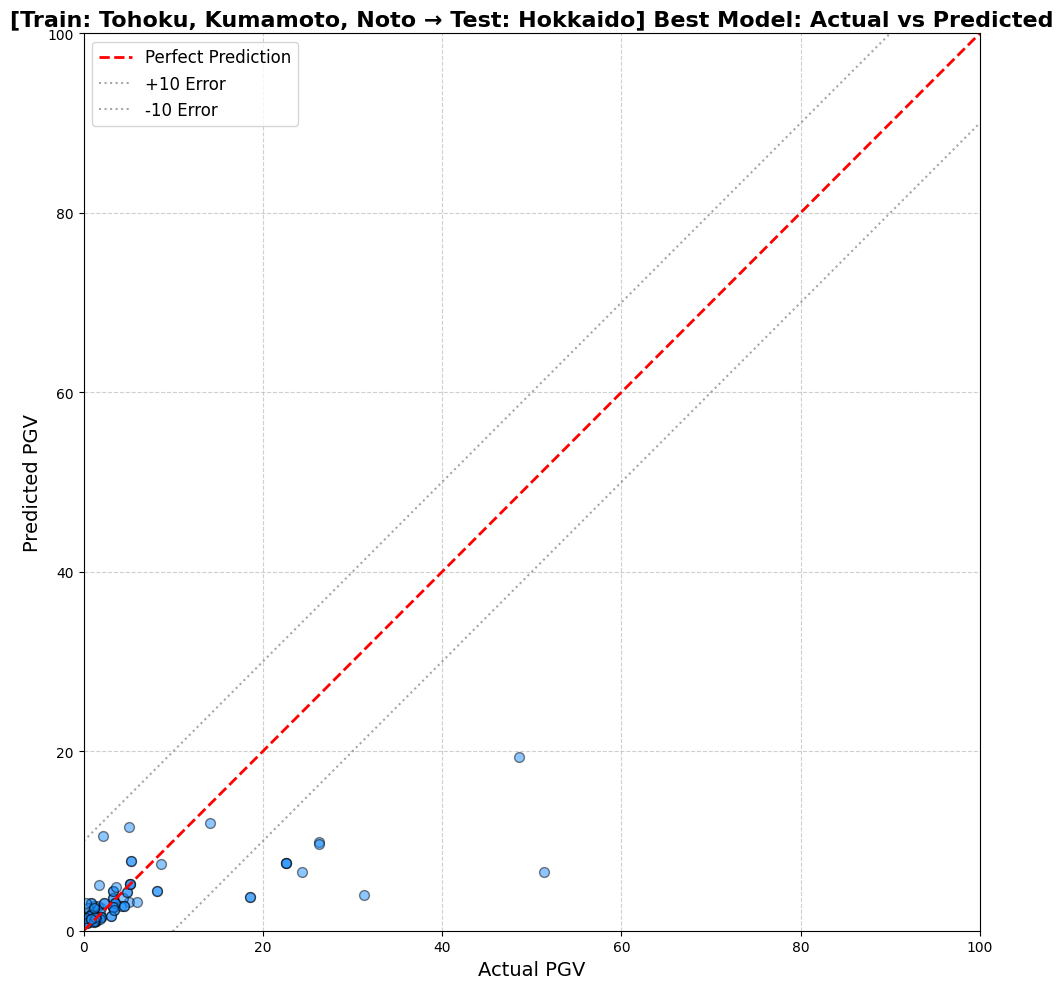

In [ ]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("===== [실험 2] Train: Tohoku, Kumamoto, Noto / Test: Hokkaido ====\n")
    best_model_2h, metric_2h, test_loader_2h = main(test_event="hokkaido")

    summarize(metric_2h, "Train: Tohoku, Kumamoto, Noto -> Test: Hokkaido")

    plot_best_model_predictions(best_model_2h, test_loader_2h, device, "Train: Tohoku, Kumamoto, Noto → Test: Hokkaido",
                                y_mean=metric_2h['y_mean'], y_std=metric_2h['y_std'])

# ───────────────────────────────────────────────
# 결과 저장
# ───────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/TriAI/그로쓰/Data/npy/multimodal/추가실험"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_metric_npy(metric, filename_prefix, save_dir=SAVE_DIR):
    save_data = {
        'epoch':      np.array(metric['epoch'],      dtype=np.int32),
        'train_loss': np.array(metric['train_loss'], dtype=np.float32),
        'test_loss':  np.float32(metric['test_loss']),
        'test_rmse':  np.float32(metric['test_rmse']),
        'lr':         np.array(metric['lr'],         dtype=np.float32),
    }
    save_path = os.path.join(save_dir, f"{filename_prefix}.npy")
    np.save(save_path, save_data)
    print(f"[저장 완료] {save_path}")
    return save_path

# [실험 3] Train: Tohoku, Hokkaido, Noto / Test: Kumamoto

===== [실험 3] Train: Tohoku, Hokkaido, Noto / Test: Kumamoto ====

Device: cuda
[Combined Stats] train_events=['tohoku', 'noto', 'hokkaido'] | y_mean=1.948926, y_std=1.019349 (n=468)
[Dataset] events=['tohoku', 'noto', 'hokkaido'] | 유효 샘플: 468
[Dataset] events=['kumamoto'] | 유효 샘플: 102
>> Train: kumamoto 제외 나머지 세 지진 / Val+Test: kumamoto
[Sampler] 이벤트별 샘플 수: {'tohoku': 172, 'noto': 176, 'hokkaido': 120}
============================== Train ==============================


/tmp/ipykernel_1082/406844175.py:642: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_1082/406844175.py:660: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 2.6409 | Val: 1.2981 (RMSE: 7.64)


/tmp/ipykernel_1082/406844175.py:675: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] LR: 0.000180 | Train: 1.9110 | Val: 1.2605 (RMSE: 9.61)
Epoch [3/100] LR: 0.000240 | Train: 1.3957 | Val: 0.7502 (RMSE: 7.67)
Epoch [4/100] LR: 0.000300 | Train: 1.4538 | Val: 0.4668 (RMSE: 6.26)
Epoch [5/100] LR: 0.000300 | Train: 1.3643 | Val: 0.6679 (RMSE: 6.34)
Epoch [6/100] LR: 0.000300 | Train: 1.1493 | Val: 1.4757 (RMSE: 11.95)
Epoch [7/100] LR: 0.000300 | Train: 1.2086 | Val: 0.2325 (RMSE: 3.91)
Epoch [8/100] LR: 0.000299 | Train: 1.1101 | Val: 3.8852 (RMSE: 32.76)
Epoch [9/100] LR: 0.000299 | Train: 1.1705 | Val: 1.8917 (RMSE: 15.29)
Epoch [10/100] LR: 0.000298 | Train: 0.8651 | Val: 0.2030 (RMSE: 3.49)
Epoch [11/100] LR: 0.000297 | Train: 0.8902 | Val: 0.5614 (RMSE: 6.03)
Epoch [12/100] LR: 0.000296 | Train: 0.7196 | Val: 0.2581 (RMSE: 4.07)
Epoch [13/100] LR: 0.000295 | Train: 0.8514 | Val: 0.4524 (RMSE: 7.68)
Epoch [14/100] LR: 0.000294 | Train: 0.8502 | Val: 3.9107 (RMSE: 36.08)
Epoch [15/100] LR: 0.000292 | Train: 0.7334 | Val: 0.2923 (RMSE: 4.32)
Epoch [16/

/tmp/ipykernel_1082/406844175.py:719: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 0.1616 | Test RMSE: 3.47
[저장 완료] /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/kumamoto_predicted_pgv_25km_360_180.csv

[Train: Tohoku, Hokkaido, Noto -> Test: Kumamoto] 학습 결과 요약
  Best Val RMSE    : 1.50  (Epoch 18)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.6065
  최종 Val Loss    : 0.5131
--------------------------------------------------------------------
  최종 Test Loss   : 0.1616
  최종 Test RMSE   : 3.47


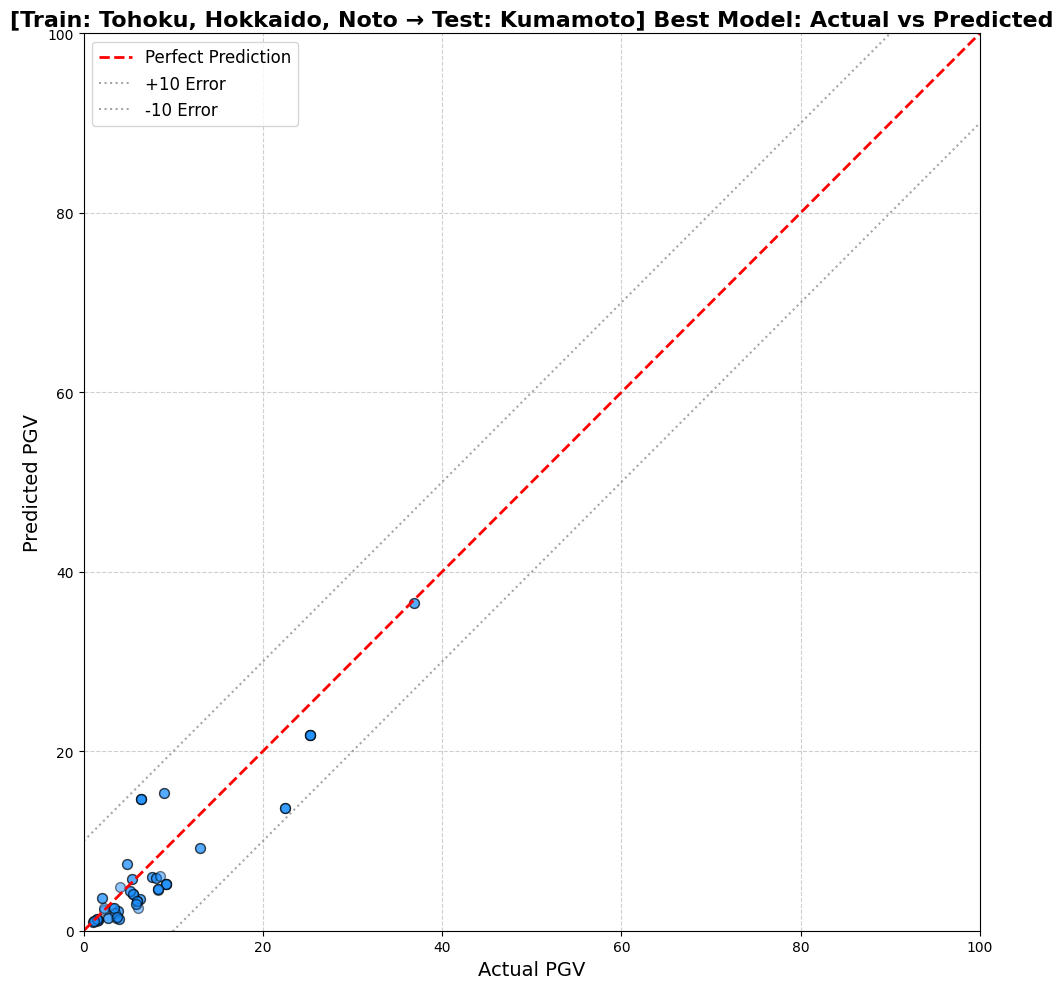

In [ ]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("===== [실험 3] Train: Tohoku, Hokkaido, Noto / Test: Kumamoto ====\n")
    best_model_2k, metric_2k, test_loader_2k = main(test_event="kumamoto")

    summarize(metric_2k, "Train: Tohoku, Hokkaido, Noto -> Test: Kumamoto")

    plot_best_model_predictions(best_model_2k, test_loader_2k, device, "Train: Tohoku, Hokkaido, Noto → Test: Kumamoto",
                                y_mean=metric_2k['y_mean'], y_std=metric_2k['y_std'])

# ───────────────────────────────────────────────
# 결과 저장
# ───────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/TriAI/그로쓰/Data/npy/multimodal/추가실험"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_metric_npy(metric, filename_prefix, save_dir=SAVE_DIR):
    save_data = {
        'epoch':      np.array(metric['epoch'],      dtype=np.int32),
        'train_loss': np.array(metric['train_loss'], dtype=np.float32),
        'test_loss':  np.float32(metric['test_loss']),
        'test_rmse':  np.float32(metric['test_rmse']),
        'lr':         np.array(metric['lr'],         dtype=np.float32),
    }
    save_path = os.path.join(save_dir, f"{filename_prefix}.npy")
    np.save(save_path, save_data)
    print(f"[저장 완료] {save_path}")
    return save_path

# [실험 4] Train: Kumamoto, Hokkaido, Noto / Test: Tohoku

===== [실험 4] Train: Kumamoto, Hokkaido, Noto / Test: Tohoku ====

Device: cuda
[Combined Stats] train_events=['noto', 'hokkaido', 'kumamoto'] | y_mean=1.554455, y_std=0.846771 (n=398)
[Dataset] events=['noto', 'hokkaido', 'kumamoto'] | 유효 샘플: 398
[Dataset] events=['tohoku'] | 유효 샘플: 172
>> Train: tohoku 제외 나머지 세 지진 / Val+Test: tohoku
[Sampler] 이벤트별 샘플 수: {'kumamoto': 102, 'noto': 176, 'hokkaido': 120}
============================== Train ==============================


/tmp/ipykernel_1082/406844175.py:642: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_1082/406844175.py:660: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1082/406844175.py:675: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 2.4891 | Val: 9.0552 (RMSE: 24.49)
Epoch [2/100] LR: 0.000180 | Train: 2.3352 | Val: 6.3073 (RMSE: 22.89)
Epoch [3/100] LR: 0.000240 | Train: 1.8257 | Val: 11.7760 (RMSE: 24.56)
Epoch [4/100] LR: 0.000300 | Train: 2.1175 | Val: 9.1629 (RMSE: 23.40)
Epoch [5/100] LR: 0.000300 | Train: 1.5111 | Val: 24.1252 (RMSE: 27.78)
Epoch [6/100] LR: 0.000300 | Train: 1.4979 | Val: 18.8842 (RMSE: 26.65)
Epoch [7/100] LR: 0.000300 | Train: 1.3199 | Val: 9.8236 (RMSE: 22.47)
Epoch [8/100] LR: 0.000299 | Train: 0.9419 | Val: 10.8713 (RMSE: 23.11)
Epoch [9/100] LR: 0.000299 | Train: 1.3326 | Val: 4.9209 (RMSE: 20.43)
Epoch [10/100] LR: 0.000298 | Train: 0.9441 | Val: 20.7706 (RMSE: 27.21)
Epoch [11/100] LR: 0.000297 | Train: 0.8713 | Val: 4.9776 (RMSE: 20.42)
Epoch [12/100] LR: 0.000296 | Train: 1.0702 | Val: 12.0956 (RMSE: 24.67)
Epoch [13/100] LR: 0.000295 | Train: 0.8392 | Val: 9.7937 (RMSE: 21.41)
Epoch [14/100] LR: 0.000294 | Train: 0.8065 | Val: 16.9404 (RMSE: 2

/tmp/ipykernel_1082/406844175.py:719: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 3.1649 | Test RMSE: 14.05
[저장 완료] /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/tohoku_predicted_pgv_25km_360_180.csv

[Train: Kumamoto, Hokkaido, Noto -> Test: Tohoku] 학습 결과 요약
  Best Val RMSE    : 16.83  (Epoch 48)
  Val Loss 스파이크: 24회
  최종 Train Loss  : 0.3030
  최종 Val Loss    : 7.0107
--------------------------------------------------------------------
  최종 Test Loss   : 3.1649
  최종 Test RMSE   : 14.05


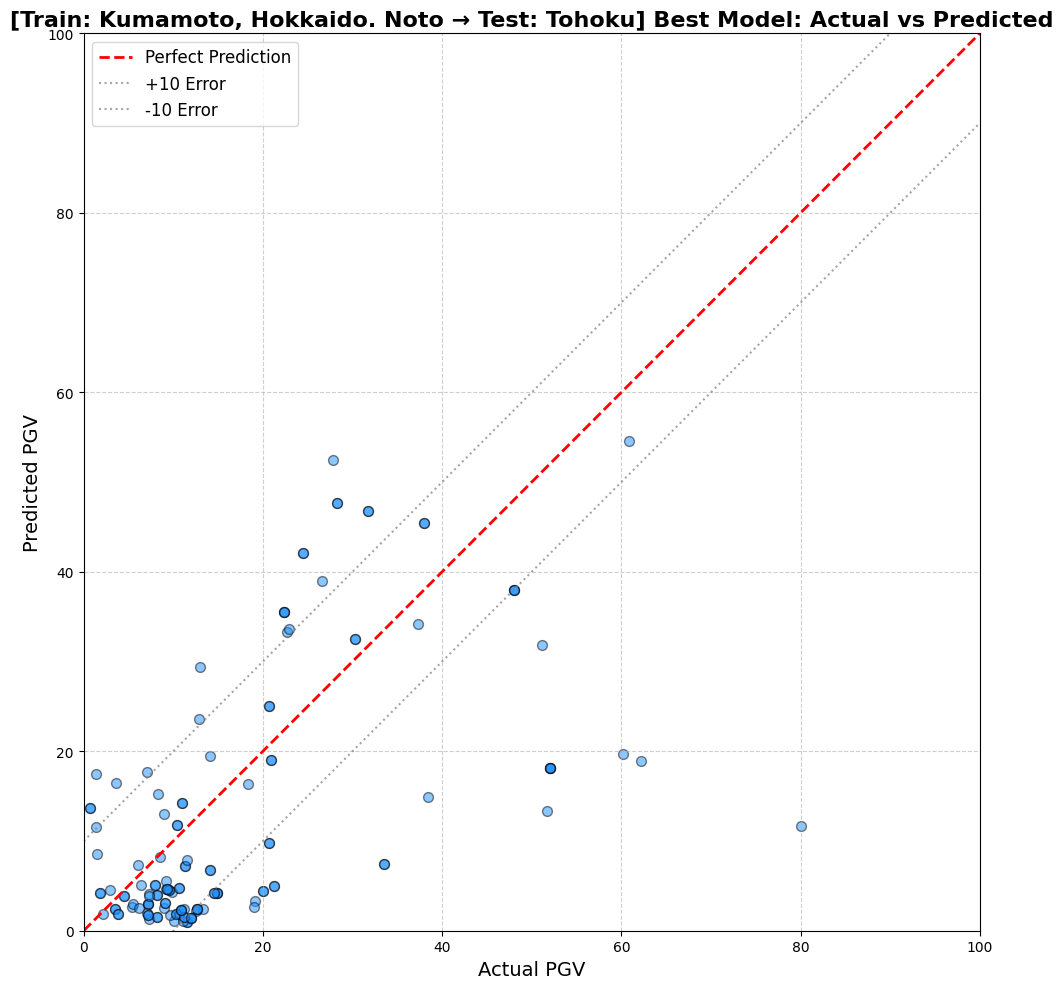

In [ ]:

if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("===== [실험 4] Train: Kumamoto, Hokkaido, Noto / Test: Tohoku ====\n")
    best_model_2t, metric_2t, test_loader_2t = main(test_event="tohoku")

    summarize(metric_2t, "Train: Kumamoto, Hokkaido, Noto -> Test: Tohoku")

    plot_best_model_predictions(best_model_2t, test_loader_2t, device, "Train: Kumamoto, Hokkaido. Noto → Test: Tohoku",
                                y_mean=metric_2t['y_mean'], y_std=metric_2t['y_std'])

# ───────────────────────────────────────────────
# 결과 저장
# ───────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/TriAI/그로쓰/Data/npy/multimodal/추가실험"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_metric_npy(metric, filename_prefix, save_dir=SAVE_DIR):
    save_data = {
        'epoch':      np.array(metric['epoch'],      dtype=np.int32),
        'train_loss': np.array(metric['train_loss'], dtype=np.float32),
        'test_loss':  np.float32(metric['test_loss']),
        'test_rmse':  np.float32(metric['test_rmse']),
        'lr':         np.array(metric['lr'],         dtype=np.float32),
    }
    save_path = os.path.join(save_dir, f"{filename_prefix}.npy")
    np.save(save_path, save_data)
    print(f"[저장 완료] {save_path}")
    return save_path

# 메모리 초기화

In [ ]:
# 메모리 초기화
import gc, torch
del best_model_2n, metric_2n, test_loader_2n
del best_model_2h, metric_2h, test_loader_2h
del best_model_2k, metric_2k, test_loader_2k
del best_model_2t, metric_2t, test_loader_2t
torch.cuda.empty_cache()
gc.collect()

3425